# Gesamtauswertung der Studienergebnisse

Dieses Notebook berechnet die vollstaendige Auswertung nacheinander aus allen
JSON-Dateien im Ordner `ergebnisse/`. Es werden **alle** Dateien in diesem Ordner
verwendet.

Wichtig: Teilnehmerzahl und Geschlechterverteilung werden **konkret gezaehlt**
und nirgends fest auf 32 / 16 / 16 gesetzt. Alle Beschriftungen und Tests nutzen
die tatsaechlich vorgefundenen Werte.

Ablauf:
1. Alle Ergebnisdateien laden und die zwei Abschlussbloecke pro Teilnehmer bestimmen
   (Android-Default vs. optimierte Funktion, robust ueber die Parameterwerte erkannt).
2. Teilnehmer und Geschlechter konkret zaehlen.
3. Gesamtvergleich Android vs. Optimized (gepaart: t-/Wilcoxon-Test, Permutation, Bootstrap-CI, Effektgroesse).
4. Vergleich nach Geschlecht (Mann-Whitney-U auf dem Delta, gemischtes Modell).
5. Vergleich nach Zieldistanz (RM-ANOVA und lineares gemischtes Modell).
6. Distanz x Geschlecht.
7. Sekundaermasse: Fehlerrate (Overshoot) und Switchbacks (McNemar / gepaart).
8. Rechtfertigt sich Personalisierung? (Streuung der optimierten Parameter, gepoolter Median).
9. Einfluss der einzelnen Parameter auf ein gutes Ergebnis.

Alle Plots werden nach `plots/` geschrieben (dieselben Dateinamen, die in der Thesis referenziert werden).


In [1]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as _mfig
from scipy import stats


# Robustes Speichern: eine gesperrte PNG (z.B. offene VS-Code-Vorschau) fuehrt nur
# zu einer Warnung statt zum Abbruch. Selbstheilend und rekursionssicher:
# 1) Aus evtl. frueher verschachtelten Wrappern die ECHTE Original-savefig holen.
# 2) Genau einen Wrapper installieren, der ausschliesslich das Original aufruft.
def _find_pristine_savefig(fn):
    seen = set()
    while getattr(fn, '__name__', '') == '_safe_savefig':
        nxt = None
        for cell in (getattr(fn, '__closure__', None) or ()):
            try:
                val = cell.cell_contents
            except ValueError:
                continue
            if callable(val) and getattr(val, '__name__', '') in ('savefig', '_safe_savefig'):
                nxt = val
                break
        if nxt is None or id(nxt) in seen:
            break
        seen.add(id(nxt))
        fn = nxt
    return fn


_pristine_savefig = _find_pristine_savefig(_mfig.Figure.savefig)


def _safe_savefig(self, fname, *args, **kwargs):
    try:
        return _pristine_savefig(self, fname, *args, **kwargs)
    except OSError as exc:
        print(f'WARN: konnte {fname} nicht speichern ({exc}).')
        print('      Tipp: Ist die PNG in einer VS-Code-Vorschau geoeffnet? '
              'Tab schliessen und Zelle erneut ausfuehren.')
        return None


_safe_savefig._is_safe_wrapper = True
_mfig.Figure.savefig = _safe_savefig


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'ergebnisse').is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
ERGEBNISSE_DIR = REPO_ROOT / 'ergebnisse'
PLOTS_DIR = REPO_ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

# Suchraum-Grenzen aus der geteilten Konfiguration (bleibt mit Frontend/Backend synchron).
BOUNDS_FILE = REPO_ROOT / 'src' / 'scrollPhysics' / 'parameterBounds.json'
with open(BOUNDS_FILE, encoding='utf-8') as fh:
    _b = json.load(fh)
PARAM_BOUNDS = {
    'scrollFriction': (float(_b['scrollFriction']['min']), float(_b['scrollFriction']['max'])),
    'decelerationRate': (float(_b['decelerationRate']['min']), float(_b['decelerationRate']['max'])),
    'inflexion': (float(_b['inflexion']['min']), float(_b['inflexion']['max'])),
}
ANDROID_DEFAULTS = {
    'scrollFriction': 0.015,
    'decelerationRate': math.log(0.78) / math.log(0.9),
    'inflexion': 0.35,
}
PARAMS = ['scrollFriction', 'decelerationRate', 'inflexion']
PARAM_LABELS = {
    'scrollFriction': 'mu (scrollFriction)',
    'decelerationRate': 'r (decelerationRate)',
    'inflexion': 'beta (inflexion)',
}
RNG = np.random.default_rng(20260930)

print('Repo root: ', REPO_ROOT)
print('Ergebnisse:', ERGEBNISSE_DIR)
print('Plots:     ', PLOTS_DIR)
print('Bounds:    ', PARAM_BOUNDS)
print('Android-Default:', {k: round(v, 4) for k, v in ANDROID_DEFAULTS.items()})


Repo root:  C:\Users\Felix\Desktop\Master\Thesis\touch-scrolling-web-app
Ergebnisse: C:\Users\Felix\Desktop\Master\Thesis\touch-scrolling-web-app\ergebnisse
Plots:      C:\Users\Felix\Desktop\Master\Thesis\touch-scrolling-web-app\plots
Bounds:     {'scrollFriction': (0.0025, 0.2), 'decelerationRate': (1.0, 10.0), 'inflexion': (0.05, 2.0)}
Android-Default: {'scrollFriction': 0.015, 'decelerationRate': 2.3582, 'inflexion': 0.35}


## 1. Dateien laden und Abschlussbloecke bestimmen

Fuer jeden Teilnehmer bilden die beiden letzten Bloecke (Runs 14 und 15) den
Innerhalb-Teilnehmer-Vergleich. Der Android-Block wird robust an seinen
Default-Parametern erkannt; der andere Abschlussblock ist die optimierte Funktion.
Falls die Erkennung scheitert, wird auf die Gruppen-Gegenbalancierung zurueckgegriffen.


In [2]:
def load_all_files(directory):
    files = sorted(Path(directory).glob('*.json'))
    participants = []
    for path in files:
        with open(path, encoding='utf-8') as fh:
            data = json.load(fh)
        items = data if isinstance(data, list) else [data]
        for item in items:
            item['_sourceFile'] = path.name
            participants.append(item)
    return files, participants


def is_android_params(ps, tol_fric=1e-3, tol_rate=1e-2, tol_infl=1e-2):
    if not ps:
        return False
    try:
        return (
            abs(float(ps.get('scrollFriction')) - ANDROID_DEFAULTS['scrollFriction']) <= tol_fric
            and abs(float(ps.get('decelerationRate')) - ANDROID_DEFAULTS['decelerationRate']) <= tol_rate
            and abs(float(ps.get('inflexion')) - ANDROID_DEFAULTS['inflexion']) <= tol_infl
        )
    except (TypeError, ValueError):
        return False


def display_name(p):
    pid = (p.get('prolificPid') or '').strip()
    return pid or (p.get('participantId') or 'unknown')


def final_condition_blocks(p):
    blocks = [b for b in (p.get('attemptBlocks') or []) if isinstance(b, dict)]
    blocks = sorted(blocks, key=lambda b: b.get('runNumber', 0))
    if len(blocks) < 2:
        return None
    last_two = blocks[-2:]
    android_block = None
    optimized_block = None
    for b in last_two:
        if is_android_params(b.get('parameterSet')):
            android_block = b
        else:
            optimized_block = b
    if android_block is None or optimized_block is None:
        # Rueckfall auf die Gegenbalancierung ueber die Studien-Gruppe.
        group = p.get('group')
        first_block, second_block = last_two[0], last_two[1]
        if group == 1:
            optimized_block, android_block = first_block, second_block
        else:
            optimized_block, android_block = second_block, first_block
    return {'android': android_block, 'optimized': optimized_block}


files, PARTICIPANTS = load_all_files(ERGEBNISSE_DIR)
print('Gefundene Dateien:', len(files))
for f in files:
    print('  -', f.name)
print('Geladene Teilnehmer-Datensaetze:', len(PARTICIPANTS))


Gefundene Dateien: 7
  - touch-scrolling-data-p1-Felix-2026-09-30.json
  - touch-scrolling-data-p2-Felix2-2026-09-30.json
  - touch-scrolling-data-p3-Anna-2026-09-30.json
  - touch-scrolling-data-p4-Lena-2026-09-30.json
  - touch-scrolling-data-p5-Woik-2026-09-30.json
  - touch-scrolling-data-p6-Henze-2026-09-30.json
  - touch-scrolling-data-p7-Freddy-2026-09-30.json
Geladene Teilnehmer-Datensaetze: 7


## 2. Trial-Tabelle bauen und konkret zaehlen

Aus den beiden Abschlussbloecken wird eine Trial-Tabelle erzeugt. Teilnehmerzahl
und Geschlechterverteilung ergeben sich ausschliesslich aus den geladenen Daten.


In [3]:
trial_rows = []
param_rows = []
skipped = []

for p in PARTICIPANTS:
    name = display_name(p)
    gender = (p.get('gender') or 'unknown').strip().lower()
    conds = final_condition_blocks(p)
    if conds is None:
        skipped.append(name)
        continue
    ops = conds['optimized'].get('parameterSet') or {}
    param_rows.append({
        'participant': name,
        'gender': gender,
        'scrollFriction': ops.get('scrollFriction'),
        'decelerationRate': ops.get('decelerationRate'),
        'inflexion': ops.get('inflexion'),
    })
    for cond_name, block in (('Android', conds['android']), ('Optimized', conds['optimized'])):
        for a in (block.get('attempts') or []):
            tn = a.get('targetNumber')
            tm = a.get('timeMs')
            if tn in (None, 0) or tm is None:
                continue
            trial_rows.append({
                'participant': name,
                'gender': gender,
                'condition': cond_name,
                'distance': int(tn),
                'timeMs': float(tm),
                'normTime': float(tm) / float(tn),
                'didOvershoot': bool(a.get('didOvershoot')),
                'overshootCount': int(a.get('overshootCount') or 0),
                'switchbackCount': int(a.get('switchbackCount') or 0),
            })

trials = pd.DataFrame(trial_rows)
opt_params = pd.DataFrame(param_rows)

N_PARTICIPANTS = int(trials['participant'].nunique())
gender_counts = (trials.drop_duplicates('participant')['gender']
                 .value_counts().to_dict())

print('Ausgewertete Teilnehmer (konkret gezaehlt):', N_PARTICIPANTS)
print('Geschlechterverteilung (konkret gezaehlt):')
for g, c in gender_counts.items():
    print('  ', g, ':', c)
if skipped:
    print('Uebersprungen (weniger als 2 Bloecke):', skipped)
print('Trials gesamt:', len(trials))
trials.head()


Ausgewertete Teilnehmer (konkret gezaehlt): 7
Geschlechterverteilung (konkret gezaehlt):
   male : 5
   female : 2
Trials gesamt: 140


,participant,gender,condition,distance,timeMs,normTime,didOvershoot,overshootCount,switchbackCount
0,Felix,male,Android,120,2652.0,22.100000,False,0,0
1,Felix,male,Android,180,3198.0,17.766667,False,0,0
2,Felix,male,Android,30,1531.0,51.033333,True,1,1
3,Felix,male,Android,240,3271.0,13.629167,False,0,0
4,Felix,male,Android,60,1244.0,20.733333,False,0,0


## 3. Ausreisser-Screening und Aggregation pro Teilnehmer

Extreme Ausreisser der Zeit werden pro Teilnehmer und Bedingung ueber eine
IQR-Regel markiert und fuer die Zeitanalyse entfernt. Danach traegt jeder
Teilnehmer je Bedingung einen Mittelwert bei.


In [4]:
def screen_outliers(df, value='timeMs', by=('participant', 'condition'), k=3.0):
    df = df.copy()
    df['is_outlier'] = False
    for _, idx in df.groupby(list(by)).groups.items():
        sub = df.loc[idx, value]
        q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
        iqr = q3 - q1
        if iqr <= 0:
            continue
        lo, hi = q1 - k * iqr, q3 + k * iqr
        df.loc[idx, 'is_outlier'] = (sub < lo) | (sub > hi)
    return df


trials = screen_outliers(trials)
n_out = int(trials['is_outlier'].sum())
print('Als Ausreisser markierte Trials:', n_out, 'von', len(trials))
trials_clean = trials[~trials['is_outlier']].copy()

subject = (trials_clean
           .groupby(['participant', 'gender', 'condition'])
           .agg(normTime=('normTime', 'mean'),
                errorRate=('didOvershoot', 'mean'),
                switchbacks=('switchbackCount', 'mean'))
           .reset_index())


def to_paired(subject_df, value):
    wide = subject_df.pivot_table(index=['participant', 'gender'],
                                  columns='condition', values=value)
    return wide.dropna()


paired_time = to_paired(subject, 'normTime')
print('Gepaarte Teilnehmer (beide Bedingungen vorhanden):', len(paired_time))
paired_time


Als Ausreisser markierte Trials: 0 von 140
Gepaarte Teilnehmer (beide Bedingungen vorhanden): 7


,condition,Android,Optimized
participant,gender,,
Anna,female,20.768497,19.104906
Felix,male,20.018419,18.968317
Felix2,male,21.262311,16.781266
Freddy,male,32.443866,40.061103
Henze,male,26.615911,26.307897
Lena,female,21.685881,13.966824
Woik,male,20.145488,17.865189


## 4. Statistik-Hilfsfunktionen

Gepaarter Vergleich mit t-Test und Wilcoxon-Test, Cohen d_z, verteilungsfreier
Vorzeichen-Permutationstest und Bootstrap-Konfidenzintervall der mittleren Differenz.
Alle Funktionen sind robust gegen kleine Stichproben.


In [5]:
def paired_stats(opt, andr, n_perm=10000):
    a = np.asarray(opt, float)
    b = np.asarray(andr, float)
    d = a - b
    n = len(d)
    out = {
        'n': n,
        'mean_opt': float(np.mean(a)) if n else float('nan'),
        'mean_and': float(np.mean(b)) if n else float('nan'),
        'mean_diff': float(np.mean(d)) if n else float('nan'),
        'shapiro_p': float('nan'), 't_p': float('nan'), 'w_p': float('nan'),
        'dz': float('nan'), 'perm_p': float('nan'),
        'ci_low': float('nan'), 'ci_high': float('nan'),
    }
    if n < 2 or np.allclose(d, 0):
        return out
    if n >= 3:
        try:
            out['shapiro_p'] = float(stats.shapiro(d).pvalue)
        except Exception:
            pass
    try:
        out['t_p'] = float(stats.ttest_rel(a, b).pvalue)
    except Exception:
        pass
    try:
        out['w_p'] = float(stats.wilcoxon(a, b).pvalue)
    except Exception:
        pass
    sd = np.std(d, ddof=1)
    out['dz'] = float(np.mean(d) / sd) if sd > 0 else float('nan')
    obs = abs(np.mean(d))
    mag = np.abs(d)
    count = 0
    for _ in range(n_perm):
        signs = RNG.choice([-1.0, 1.0], size=n)
        if abs(np.mean(signs * mag)) >= obs - 1e-12:
            count += 1
    out['perm_p'] = (count + 1) / (n_perm + 1)
    boot = np.empty(n_perm)
    for i in range(n_perm):
        idx = RNG.integers(0, n, n)
        boot[i] = np.mean(d[idx])
    out['ci_low'] = float(np.percentile(boot, 2.5))
    out['ci_high'] = float(np.percentile(boot, 97.5))
    return out


def fmt(x, nd=4):
    if x is None:
        return 'n/a'
    try:
        if isinstance(x, float) and math.isnan(x):
            return 'n/a'
    except TypeError:
        return 'n/a'
    return f'{x:.{nd}f}'


## 5. Gesamtvergleich: Android vs. Optimized

Alle Teilnehmer gepoolt. Negative Differenz (Opt - And) bedeutet: die optimierte
Funktion war schneller.


Gesamtvergleich (n = 7 )
  Mittel Android   : 23.2772
  Mittel Optimized : 21.8651
  Differenz Opt-And: -1.4121
  Shapiro p (Diff) : 0.3929
  paired t p       : 0.4575
  Wilcoxon p       : 0.2188
  Permutation p    : 0.4102
  Cohen dz         : -0.3001
  95% Bootstrap-CI : -4.3199 bis 2.0496

Fehlerrate (Overshoot-Anteil): And= 0.5143  Opt= 0.6286  diff= 0.1143  Wilcoxon p= 0.4688
Switchbacks pro Trial        : And= 0.3714  Opt= 0.3857  diff= 0.0143  Wilcoxon p= 1.0000


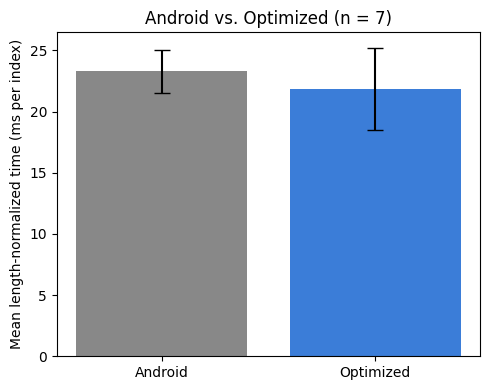

In [6]:
res_overall = paired_stats(paired_time['Optimized'], paired_time['Android'])
print('Gesamtvergleich (n =', res_overall['n'], ')')
print('  Mittel Android   :', fmt(res_overall['mean_and']))
print('  Mittel Optimized :', fmt(res_overall['mean_opt']))
print('  Differenz Opt-And:', fmt(res_overall['mean_diff']))
print('  Shapiro p (Diff) :', fmt(res_overall['shapiro_p']))
print('  paired t p       :', fmt(res_overall['t_p']))
print('  Wilcoxon p       :', fmt(res_overall['w_p']))
print('  Permutation p    :', fmt(res_overall['perm_p']))
print('  Cohen dz         :', fmt(res_overall['dz']))
print('  95% Bootstrap-CI :', fmt(res_overall['ci_low']), 'bis', fmt(res_overall['ci_high']))

paired_err = to_paired(subject, 'errorRate')
paired_sw = to_paired(subject, 'switchbacks')
res_err = paired_stats(paired_err['Optimized'], paired_err['Android'])
res_sw = paired_stats(paired_sw['Optimized'], paired_sw['Android'])
print()
print('Fehlerrate (Overshoot-Anteil): And=', fmt(res_err['mean_and']),
      ' Opt=', fmt(res_err['mean_opt']), ' diff=', fmt(res_err['mean_diff']),
      ' Wilcoxon p=', fmt(res_err['w_p']))
print('Switchbacks pro Trial        : And=', fmt(res_sw['mean_and']),
      ' Opt=', fmt(res_sw['mean_opt']), ' diff=', fmt(res_sw['mean_diff']),
      ' Wilcoxon p=', fmt(res_sw['w_p']))

means = [res_overall['mean_and'], res_overall['mean_opt']]
sems = [subject[subject.condition == 'Android']['normTime'].sem(),
        subject[subject.condition == 'Optimized']['normTime'].sem()]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Android', 'Optimized'], means, yerr=sems, capsize=6,
       color=['#888888', '#3b7dd8'])
ax.set_ylabel('Mean length-normalized time (ms per index)')
ax.set_title(f'Android vs. Optimized (n = {N_PARTICIPANTS})')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'eval_android_vs_optimized_overall.png', dpi=150)
plt.show()


## 6. Vergleich nach Geschlecht

Gruppen werden konkret aus den Daten bestimmt. Innerhalb jeder Gruppe wird der
gepaarte Vergleich wiederholt; zwischen den Gruppen wird das Delta (Opt - And)
mit dem Mann-Whitney-U-Test verglichen. Ein gemischtes Modell liefert die
parametrische Entsprechung (Function x Gender).


Vorgefundene Geschlechtsgruppen: ['female', 'male']
  female (n=2): And=21.2272 Opt=16.5359 diff=-4.6913 t_p=0.3649 W_p=0.5000 dz=-1.0956
  male (n=5): And=24.0972 Opt=23.9968 diff=-0.1004 t_p=0.9634 W_p=0.6250 dz=-0.0219
  Mann-Whitney U auf Delta (female vs male): p=0.3810
                         Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            normTime
No. Observations:            14                 Method:                        REML    
No. Groups:                  7                  Scale:                         10.2783 
Min. group size:             2                  Log-Likelihood:                -33.6045
Max. group size:             2                  Converged:                     Yes     
Mean group size:             2.0                                                       
---------------------------------------------------------------------------------------
                                            C

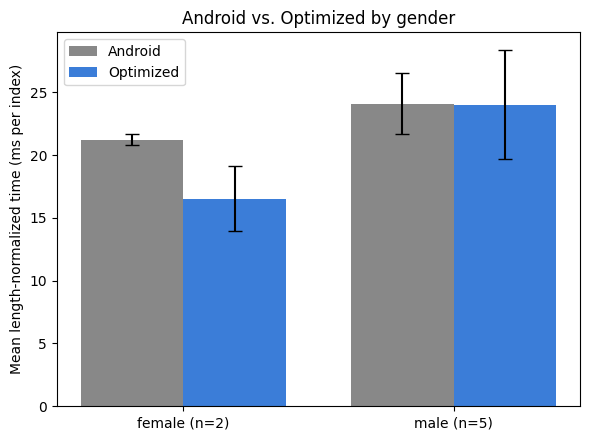

In [7]:
groups = sorted(subject['gender'].unique())
print('Vorgefundene Geschlechtsgruppen:', groups)

gender_time = to_paired(subject, 'normTime').reset_index()
gender_time['delta'] = gender_time['Optimized'] - gender_time['Android']

per_group = {}
for g in groups:
    sub = gender_time[gender_time['gender'] == g]
    if len(sub) == 0:
        continue
    r = paired_stats(sub['Optimized'], sub['Android'])
    per_group[g] = r
    ng = r['n']
    print(f'  {g} (n={ng}): And={fmt(r["mean_and"])} Opt={fmt(r["mean_opt"])} '
          f'diff={fmt(r["mean_diff"])} t_p={fmt(r["t_p"])} W_p={fmt(r["w_p"])} dz={fmt(r["dz"])}')

if len(groups) >= 2:
    a_delta = gender_time[gender_time['gender'] == groups[0]]['delta']
    b_delta = gender_time[gender_time['gender'] == groups[1]]['delta']
    if len(a_delta) > 0 and len(b_delta) > 0:
        try:
            u = stats.mannwhitneyu(a_delta, b_delta, alternative='two-sided')
            print(f'  Mann-Whitney U auf Delta ({groups[0]} vs {groups[1]}): p={fmt(u.pvalue)}')
        except Exception as exc:
            print('  Mann-Whitney nicht berechenbar:', exc)
else:
    print('  Nur eine Geschlechtsgruppe vorhanden - kein Zwischengruppen-Vergleich moeglich.')

try:
    import statsmodels.formula.api as smf
    if len(groups) >= 2:
        mm = smf.mixedlm('normTime ~ C(condition) * C(gender)', subject,
                         groups=subject['participant']).fit()
        print(mm.summary())
    else:
        print('  Gemischtes Modell uebersprungen (nur eine Geschlechtsgruppe).')
except Exception as exc:
    print('  Gemischtes Modell nicht berechenbar:', exc)

if groups:
    x = np.arange(len(groups))
    width = 0.38
    and_means = [subject[(subject.gender == g) & (subject.condition == 'Android')]['normTime'].mean() for g in groups]
    opt_means = [subject[(subject.gender == g) & (subject.condition == 'Optimized')]['normTime'].mean() for g in groups]
    and_sem = [subject[(subject.gender == g) & (subject.condition == 'Android')]['normTime'].sem() for g in groups]
    opt_sem = [subject[(subject.gender == g) & (subject.condition == 'Optimized')]['normTime'].sem() for g in groups]
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.bar(x - width / 2, and_means, width, yerr=and_sem, capsize=5, label='Android', color='#888888')
    ax.bar(x + width / 2, opt_means, width, yerr=opt_sem, capsize=5, label='Optimized', color='#3b7dd8')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{g} (n={gender_counts.get(g, 0)})' for g in groups])
    ax.set_ylabel('Mean length-normalized time (ms per index)')
    ax.set_title('Android vs. Optimized by gender')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'eval_android_vs_optimized_by_gender.png', dpi=150)
    plt.show()


## 7. Vergleich nach Zieldistanz

Hier wird die rohe Zeit `timeMs` verwendet, da die Distanz jetzt ein expliziter
Faktor ist. RM-ANOVA (Function x Distance) und ein lineares gemischtes Modell
werden angepasst; beide sind gegen kleine/unbalancierte Daten abgesichert.


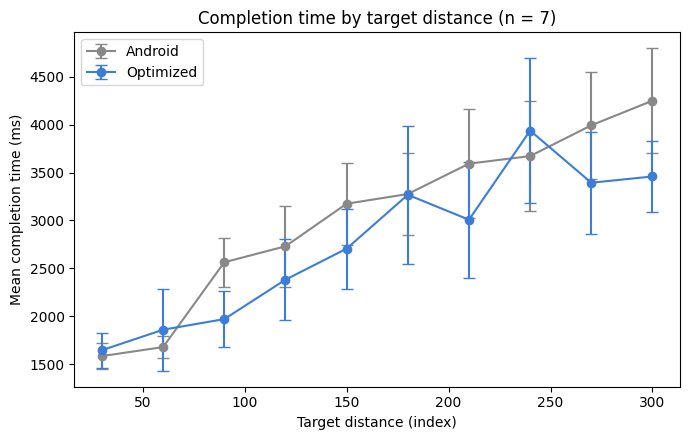

                      F Value  Num DF  Den DF        Pr > F
condition            6.154763     1.0     6.0  4.774842e-02
distance            12.588999     9.0    54.0  1.733268e-10
condition:distance   1.659773     9.0    54.0  1.219064e-01
                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          timeMs     
No. Observations:            140              Method:                      REML       
No. Groups:                  7                Scale:                       518362.3389
Min. group size:             20               Log-Likelihood:              -1116.2768 
Max. group size:             20               Converged:                   Yes        
Mean group size:             20.0                                                     
--------------------------------------------------------------------------------------
                                      Coef.    Std.Err.   z    P>|z|  [0.025   0.975] 
--

In [8]:
dist_means = (trials_clean.groupby(['condition', 'distance'])['timeMs']
              .agg(['mean', 'sem']).reset_index())

fig, ax = plt.subplots(figsize=(7, 4.5))
for cond, color in (('Android', '#888888'), ('Optimized', '#3b7dd8')):
    sub = dist_means[dist_means.condition == cond].sort_values('distance')
    ax.errorbar(sub['distance'], sub['mean'], yerr=sub['sem'], marker='o',
                capsize=4, label=cond, color=color)
ax.set_xlabel('Target distance (index)')
ax.set_ylabel('Mean completion time (ms)')
ax.set_title(f'Completion time by target distance (n = {N_PARTICIPANTS})')
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'eval_android_vs_optimized_by_distance.png', dpi=150)
plt.show()

rm_df = (trials_clean.groupby(['participant', 'condition', 'distance'])['timeMs']
         .mean().reset_index())
try:
    from statsmodels.stats.anova import AnovaRM
    aov = AnovaRM(rm_df, 'timeMs', 'participant', within=['condition', 'distance']).fit()
    print(aov.anova_table)
except Exception as exc:
    print('RM-ANOVA nicht berechenbar (evtl. zu wenige/unbalancierte Daten):', exc)

try:
    import statsmodels.formula.api as smf
    lmm = smf.mixedlm('timeMs ~ C(condition) * distance', rm_df,
                      groups=rm_df['participant']).fit()
    print(lmm.summary())
except Exception as exc:
    print('Lineares gemischtes Modell nicht berechenbar:', exc)


## 8. Distanz x Geschlecht

Dieselben Distanzprofile getrennt nach Geschlecht.


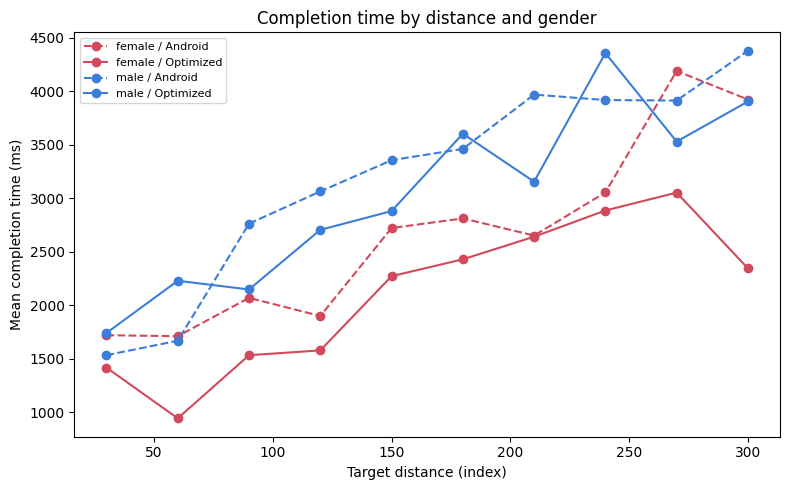

In [9]:
palette = ['#d1495b', '#3b7dd8', '#2a9d8f', '#e9c46a', '#9b5de5']
styles = {'Android': '--', 'Optimized': '-'}
genders_present = sorted(trials_clean['gender'].unique())
colors = {g: palette[i % len(palette)] for i, g in enumerate(genders_present)}

fig, ax = plt.subplots(figsize=(8, 5))
for g in genders_present:
    for cond in ('Android', 'Optimized'):
        sub = (trials_clean[(trials_clean.gender == g) & (trials_clean.condition == cond)]
               .groupby('distance')['timeMs'].mean().reset_index().sort_values('distance'))
        if len(sub) == 0:
            continue
        ax.plot(sub['distance'], sub['timeMs'], styles[cond], marker='o',
                color=colors[g], label=f'{g} / {cond}')
ax.set_xlabel('Target distance (index)')
ax.set_ylabel('Mean completion time (ms)')
ax.set_title('Completion time by distance and gender')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'eval_android_vs_optimized_by_distance_gender.png', dpi=150)
plt.show()


## 9. Sekundaermasse: Overshoot (Fehlerrate) und Switchbacks

Der Overshoot dient als Genauigkeits-Proxy. Gepaart pro (Teilnehmer, Distanz)
wird eine 2x2-Tabelle gebildet und mit McNemar getestet.


In [10]:
piv = trials_clean.pivot_table(index=['participant', 'distance'],
                               columns='condition', values='didOvershoot').dropna()
both = int(((piv['Optimized'] == True) & (piv['Android'] == True)).sum())
opt_only = int(((piv['Optimized'] == True) & (piv['Android'] == False)).sum())
and_only = int(((piv['Optimized'] == False) & (piv['Android'] == True)).sum())
neither = int(((piv['Optimized'] == False) & (piv['Android'] == False)).sum())
print('Gepaarte Overshoot-Tabelle (pro Teilnehmer/Distanz):')
print('  beide=', both, ' nur Optimized=', opt_only, ' nur Android=', and_only, ' keiner=', neither)
try:
    from statsmodels.stats.contingency_tables import mcnemar
    exact = (opt_only + and_only) < 25
    mc = mcnemar([[both, opt_only], [and_only, neither]], exact=exact)
    print('  McNemar p:', fmt(mc.pvalue))
except Exception as exc:
    print('  McNemar nicht berechenbar:', exc)

print()
print('Fehlerrate gepaart : Wilcoxon p =', fmt(res_err['w_p']),
      ' Permutation p =', fmt(res_err['perm_p']))
print('Switchbacks gepaart: Wilcoxon p =', fmt(res_sw['w_p']),
      ' Permutation p =', fmt(res_sw['perm_p']))


Gepaarte Overshoot-Tabelle (pro Teilnehmer/Distanz):
  beide= 23  nur Optimized= 21  nur Android= 13  keiner= 13
  McNemar p: 0.2299

Fehlerrate gepaart : Wilcoxon p = 0.4688  Permutation p = 0.4373
Switchbacks gepaart: Wilcoxon p = 1.0000  Permutation p = 1.0000


## 10. Rechtfertigt sich Personalisierung?

Streuung der optimierten Parameter ueber alle Teilnehmer, jeweils relativ zur
Breite des Suchraums. Eng geclusterte Optima sprechen fuer eine gepoolte Funktion,
breite Streuung fuer Personalisierung. Zusaetzlich der gepoolte Median-Parametersatz
als deskriptiver Vergleichspunkt (kein Performance-Vergleich - dazu fehlt eine
Messung unter der gepoolten Funktion, siehe Thesis / Future Work).


Teilnehmer mit optimierten Parametern: 7
Streuung der optimierten Parameter (konkret ueber 7 Teilnehmer):
  mu (scrollFriction): median=0.1640 IQR=0.0700 (35.4% der Spanne) range=0.1010 (51.1% der Spanne)
  r (decelerationRate): median=9.0858 IQR=3.3097 (36.8% der Spanne) range=4.4112 (49.0% der Spanne)
  beta (inflexion): median=1.4400 IQR=0.2750 (14.1% der Spanne) range=0.9400 (48.2% der Spanne)


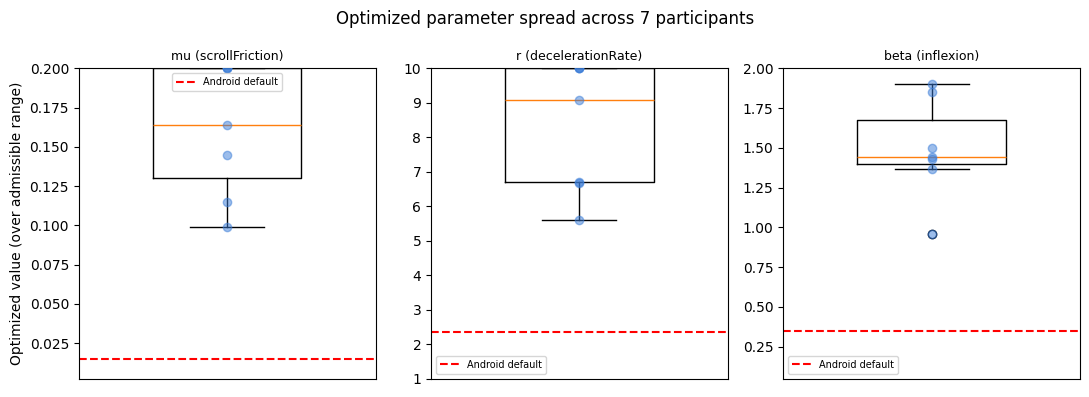

Gepoolter Median-Parametersatz: {'scrollFriction': 0.164, 'decelerationRate': 9.0858, 'inflexion': 1.44}
Normierter Abstand jedes Optimums zum gepoolten Median:
  mean=0.3240  median=0.3444  max=0.3902


In [11]:
pdf = opt_params.dropna(subset=PARAMS).copy()
n_opt = len(pdf)
print('Teilnehmer mit optimierten Parametern:', n_opt)
print('Streuung der optimierten Parameter (konkret ueber', n_opt, 'Teilnehmer):')
spread_rows = []
for name in PARAMS:
    vals = opt_params[name].dropna().to_numpy(float)
    if len(vals) == 0:
        continue
    lo, hi = PARAM_BOUNDS[name]
    width = hi - lo
    med = float(np.median(vals))
    q1 = float(np.percentile(vals, 25))
    q3 = float(np.percentile(vals, 75))
    iqr = q3 - q1
    rng = float(vals.max() - vals.min())
    spread_rows.append({'param': name, 'median': med, 'iqr': iqr, 'range': rng,
                        'iqr_pct_of_range': 100 * iqr / width,
                        'range_pct_of_range': 100 * rng / width})
    print(f'  {PARAM_LABELS[name]}: median={med:.4f} IQR={iqr:.4f} '
          f'({100 * iqr / width:.1f}% der Spanne) range={rng:.4f} '
          f'({100 * rng / width:.1f}% der Spanne)')
spread_df = pd.DataFrame(spread_rows)

fig, axes = plt.subplots(1, len(PARAMS), figsize=(11, 4))
axes = np.atleast_1d(axes)
for ax, name in zip(axes, PARAMS):
    vals = opt_params[name].dropna().to_numpy(float)
    lo, hi = PARAM_BOUNDS[name]
    if len(vals) > 0:
        ax.boxplot(vals, vert=True, widths=0.5)
        ax.scatter(np.ones_like(vals), vals, alpha=0.5, color='#3b7dd8', zorder=3)
    ax.axhline(ANDROID_DEFAULTS[name], color='red', linestyle='--', label='Android default')
    ax.set_ylim(lo, hi)
    ax.set_title(PARAM_LABELS[name], fontsize=9)
    ax.set_xticks([])
    ax.legend(fontsize=7)
axes[0].set_ylabel('Optimized value (over admissible range)')
fig.suptitle(f'Optimized parameter spread across {n_opt} participants')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'eval_optimized_param_spread.png', dpi=150)
plt.show()

if n_opt >= 1:
    med_vec = {name: float(np.median(opt_params[name].dropna())) for name in PARAMS}
    print('Gepoolter Median-Parametersatz:', {k: round(v, 4) for k, v in med_vec.items()})
    dists = []
    for _, row in opt_params.dropna(subset=PARAMS).iterrows():
        acc = 0.0
        for name in PARAMS:
            lo, hi = PARAM_BOUNDS[name]
            acc += ((row[name] - med_vec[name]) / (hi - lo)) ** 2
        dists.append(math.sqrt(acc))
    dists = np.array(dists)
    print('Normierter Abstand jedes Optimums zum gepoolten Median:')
    print(f'  mean={dists.mean():.4f}  median={np.median(dists):.4f}  max={dists.max():.4f}')


## 11. Zusammenfassung

Kompakte Ausgabe der zentralen, konkret gezaehlten Ergebnisse.


In [15]:
print('=== Zusammenfassung (alle Werte aus den Daten, nichts fest kodiert) ===')
print('Dateien im Ordner ergebnisse/ :', len(files))
print('Ausgewertete Teilnehmer       :', N_PARTICIPANTS)
print('Geschlechterverteilung        :', gender_counts)
print()
print('Gesamt Android vs. Optimized  :')
print('  Android   mean normTime =', fmt(res_overall['mean_and']))
print('  Optimized mean normTime =', fmt(res_overall['mean_opt']))
print('  Differenz (Opt-And)     =', fmt(res_overall['mean_diff']),
      '  95% CI [', fmt(res_overall['ci_low']), ',', fmt(res_overall['ci_high']), ']')
print('  paired t p =', fmt(res_overall['t_p']),
      '  Wilcoxon p =', fmt(res_overall['w_p']),
      '  Permutation p =', fmt(res_overall['perm_p']),
      '  Cohen dz =', fmt(res_overall['dz']))
print()
print('Sekundaer:')
print('  Fehlerrate diff (Opt-And) =', fmt(res_err['mean_diff']), '  Wilcoxon p =', fmt(res_err['w_p']))
print('  Switchbacks diff (Opt-And)=', fmt(res_sw['mean_diff']), '  Wilcoxon p =', fmt(res_sw['w_p']))
print()
print('Plots geschrieben nach:', PLOTS_DIR)
for name in ['eval_android_vs_optimized_overall.png',
             'eval_android_vs_optimized_by_gender.png',
             'eval_android_vs_optimized_by_distance.png',
             'eval_android_vs_optimized_by_distance_gender.png',
             'eval_optimized_param_spread.png']:
    exists = (PLOTS_DIR / name).exists()
    print('  ', name, '->', 'ok' if exists else 'fehlt')


=== Zusammenfassung (alle Werte aus den Daten, nichts fest kodiert) ===
Dateien im Ordner ergebnisse/ : 7
Ausgewertete Teilnehmer       : 7
Geschlechterverteilung        : {'male': 5, 'female': 2}

Gesamt Android vs. Optimized  :
  Android   mean normTime = 23.2772
  Optimized mean normTime = 21.8651
  Differenz (Opt-And)     = -1.4121   95% CI [ -4.3199 , 2.0496 ]
  paired t p = 0.4575   Wilcoxon p = 0.2188   Permutation p = 0.4102   Cohen dz = -0.3001

Sekundaer:
  Fehlerrate diff (Opt-And) = 0.1143   Wilcoxon p = 0.4688
  Switchbacks diff (Opt-And)= 0.0143   Wilcoxon p = 1.0000

Parameter-Einfluss (standardisiert, negativ = besser):
   mu (scrollFriction) : beta = 0.138   p = 0.0410
   r (decelerationRate) : beta = -0.364   p = 0.0000
   beta (inflexion) : beta = -0.163   p = 0.0085

Plots geschrieben nach: C:\Users\Felix\Desktop\Master\Thesis\touch-scrolling-web-app\plots
   eval_android_vs_optimized_overall.png -> ok
   eval_android_vs_optimized_by_gender.png -> ok
   eval_android

## 12. Export für die Thesis (CSV)

Alle berechneten Kennzahlen werden in eine einzige Datei `plots/eval_results.csv`
geschrieben (Spalten `key, value, label, unit`). Die Thesis liest jeden Wert über
seinen `key` mit dem `datatool`-Paket aus. Zusammen mit den Plots im selben Ordner
sind CSV und Abbildungen dadurch **austauschbar**: neue Daten → Notebook erneut
ausführen → beim nächsten Kompilieren übernimmt die Thesis automatisch die neuen Werte.


In [16]:
# Alle Kennzahlen als eine CSV fuer die Thesis exportieren (Spalten: key,value,label,unit).
# Die Thesis liest jeden Wert ueber seinen 'key' aus -> CSV und Plots sind austauschbar:
# neue Daten -> Notebook neu ausfuehren -> Thesis aktualisiert sich beim naechsten Kompilieren.
# Keys sind camelCase (keine Unterstriche), damit sie in LaTeX direkt als \evalval{key} nutzbar sind.
def _num(x, nd=2):
    try:
        xf = float(x)
    except (TypeError, ValueError):
        return 'NA'
    if math.isnan(xf):
        return 'NA'
    return f'{xf:.{nd}f}'


def _cap(base):
    return base[0].upper() + base[1:]


rows = []


def add(key, value, label, unit=''):
    # Labels/Units kommafrei und ohne '%' halten, damit die CSV fuer datatool robust bleibt.
    rows.append({'key': key, 'value': value,
                 'label': label.replace(',', ';'),
                 'unit': unit.replace('%', 'pct')})


# Meta / Zaehlungen
add('nParticipants', str(int(N_PARTICIPANTS)), 'Number of evaluated participants')
add('nFemale', str(int(gender_counts.get('female', 0))), 'Number of female participants')
add('nMale', str(int(gender_counts.get('male', 0))), 'Number of male participants')
add('nFiles', str(len(files)), 'Number of result files')

# Gesamtvergleich (laengen-normalisierte Zeit, ms/index)
_ma = res_overall['mean_and']
pct_impr = ((_ma - res_overall['mean_opt']) / _ma * 100.0
            if isinstance(_ma, (int, float)) and _ma not in (0, None) and not math.isnan(_ma)
            else float('nan'))
add('overallAndroidMean', _num(res_overall['mean_and']), 'Mean length-normalized time Android', 'ms/index')
add('overallOptimizedMean', _num(res_overall['mean_opt']), 'Mean length-normalized time Optimized', 'ms/index')
add('overallDiff', _num(res_overall['mean_diff']), 'Mean difference (Optimized minus Android)', 'ms/index')
add('overallPctImprovement', _num(pct_impr, 1), 'Relative improvement of Optimized over Android', '%')
add('overallCiLow', _num(res_overall['ci_low']), 'Lower 95pct bootstrap CI of mean difference', 'ms/index')
add('overallCiHigh', _num(res_overall['ci_high']), 'Upper 95pct bootstrap CI of mean difference', 'ms/index')
add('overallCohenDz', _num(res_overall['dz']), 'Cohen dz effect size (paired)')
add('overallTp', _num(res_overall['t_p'], 4), 'Paired t-test p-value')
add('overallWilcoxonP', _num(res_overall['w_p'], 4), 'Wilcoxon signed-rank p-value')
add('overallPermP', _num(res_overall['perm_p'], 4), 'Sign-flip permutation p-value')
add('overallShapiroP', _num(res_overall['shapiro_p'], 4), 'Shapiro-Wilk p-value of paired differences')

# Sekundaermasse
add('errAndroid', _num(res_err['mean_and'], 3), 'Overshoot error rate Android')
add('errOptimized', _num(res_err['mean_opt'], 3), 'Overshoot error rate Optimized')
add('errDiff', _num(res_err['mean_diff'], 3), 'Error-rate difference (Optimized minus Android)')
add('errWilcoxonP', _num(res_err['w_p'], 4), 'Error-rate Wilcoxon p-value')
add('swAndroid', _num(res_sw['mean_and'], 3), 'Switchbacks per trial Android')
add('swOptimized', _num(res_sw['mean_opt'], 3), 'Switchbacks per trial Optimized')
add('swDiff', _num(res_sw['mean_diff'], 3), 'Switchback difference (Optimized minus Android)')
add('swWilcoxonP', _num(res_sw['w_p'], 4), 'Switchback Wilcoxon p-value')

# Overshoot-Kreuztabelle + McNemar
add('overshootBoth', str(int(both)), 'Overshoot in both conditions (count)')
add('overshootOptOnly', str(int(opt_only)), 'Overshoot only under Optimized (count)')
add('overshootAndOnly', str(int(and_only)), 'Overshoot only under Android (count)')
add('overshootNeither', str(int(neither)), 'Overshoot in neither condition (count)')
_mc = globals().get('mc')
add('mcnemarP', _num(getattr(_mc, 'pvalue', float('nan')), 4), 'McNemar p-value (paired overshoot)')

# Nach Geschlecht
for _g in ('female', 'male'):
    _gc = _cap(_g)
    _r = per_group.get(_g)
    if _r is None:
        for _suf in ('N', 'Android', 'Optimized', 'Diff', 'Tp', 'WilcoxonP', 'Dz'):
            add(f'gender{_gc}{_suf}', 'NA', f'{_g} {_suf} (not available)')
        continue
    add(f'gender{_gc}N', str(int(_r['n'])), f'Number of {_g} participants (paired)')
    add(f'gender{_gc}Android', _num(_r['mean_and']), f'Mean norm. time Android {_g}', 'ms/index')
    add(f'gender{_gc}Optimized', _num(_r['mean_opt']), f'Mean norm. time Optimized {_g}', 'ms/index')
    add(f'gender{_gc}Diff', _num(_r['mean_diff']), f'Mean difference (Opt minus And) {_g}', 'ms/index')
    add(f'gender{_gc}Tp', _num(_r['t_p'], 4), f'Paired t-test p {_g}')
    add(f'gender{_gc}WilcoxonP', _num(_r['w_p'], 4), f'Wilcoxon p {_g}')
    add(f'gender{_gc}Dz', _num(_r['dz']), f'Cohen dz {_g}')
_u = globals().get('u')
add('mannwhitneyDeltaP', _num(getattr(_u, 'pvalue', float('nan')), 4), 'Mann-Whitney U p on gender delta')

# Distanz: RM-ANOVA
_aov = globals().get('aov')


def _aov_get(term, col):
    try:
        return float(_aov.anova_table.loc[term, col])
    except Exception:
        return float('nan')


add('rmanovaConditionF', _num(_aov_get('condition', 'F Value')), 'RM-ANOVA F Function')
add('rmanovaConditionP', _num(_aov_get('condition', 'Pr > F'), 4), 'RM-ANOVA p Function')
add('rmanovaDistanceF', _num(_aov_get('distance', 'F Value')), 'RM-ANOVA F Distance')
add('rmanovaDistanceP', _num(_aov_get('distance', 'Pr > F'), 4), 'RM-ANOVA p Distance')
add('rmanovaInteractionF', _num(_aov_get('condition:distance', 'F Value')), 'RM-ANOVA F Function x Distance')
add('rmanovaInteractionP', _num(_aov_get('condition:distance', 'Pr > F'), 4), 'RM-ANOVA p Function x Distance')

# Distanz: lineares gemischtes Modell
_lmm = globals().get('lmm')


def _lmm_get(name, which):
    try:
        s = _lmm.params if which == 'coef' else _lmm.pvalues
        return float(s.get(name))
    except Exception:
        return float('nan')


add('lmmConditionCoef', _num(_lmm_get('C(condition)[T.Optimized]', 'coef')), 'LMM coef Function', 'ms')
add('lmmConditionP', _num(_lmm_get('C(condition)[T.Optimized]', 'p'), 4), 'LMM p Function')
add('lmmDistanceCoef', _num(_lmm_get('distance', 'coef'), 3), 'LMM coef Distance', 'ms/index')
add('lmmDistanceP', _num(_lmm_get('distance', 'p'), 4), 'LMM p Distance')
add('lmmInteractionCoef', _num(_lmm_get('C(condition)[T.Optimized]:distance', 'coef'), 3), 'LMM coef Function x Distance', 'ms/index')
add('lmmInteractionP', _num(_lmm_get('C(condition)[T.Optimized]:distance', 'p'), 4), 'LMM p Function x Distance')

# Personalisierung: Streuung + gepoolter Median
_sp = {row['param']: row for _, row in spread_df.iterrows()} if len(spread_df) else {}
for _base in PARAMS:
    _bc = _cap(_base)
    _r = _sp.get(_base)
    if _r is None:
        continue
    add(f'spread{_bc}Median', _num(_r['median'], 4), f'Median optimized value {PARAM_LABELS[_base]}')
    add(f'spread{_bc}Iqr', _num(_r['iqr'], 4), f'IQR of optimized value {PARAM_LABELS[_base]}')
    add(f'spread{_bc}Range', _num(_r['range'], 4), f'Range of optimized value {PARAM_LABELS[_base]}')
    add(f'spread{_bc}IqrPct', _num(_r['iqr_pct_of_range'], 1), f'IQR as pct of search range {PARAM_LABELS[_base]}', '%')
    add(f'spread{_bc}RangePct', _num(_r['range_pct_of_range'], 1), f'Range as pct of search range {PARAM_LABELS[_base]}', '%')

for _base in PARAMS:
    _bc = _cap(_base)
    add(f'pooledMedian{_bc}', _num(med_vec.get(_base), 4), f'Pooled-median parameter {PARAM_LABELS[_base]}')
add('pooledDistMean', _num(float(np.mean(dists)), 4), 'Mean normalized distance to pooled median')
add('pooledDistMedian', _num(float(np.median(dists)), 4), 'Median normalized distance to pooled median')
add('pooledDistMax', _num(float(np.max(dists)), 4), 'Max normalized distance to pooled median')

results_df = pd.DataFrame(rows, columns=['key', 'value', 'label', 'unit'])
csv_path = PLOTS_DIR / 'eval_results.csv'
try:
    results_df.to_csv(csv_path, index=False, encoding='utf-8')
    print('CSV geschrieben:', csv_path, '(', len(results_df), 'Werte )')
except OSError as exc:
    print('WARN: konnte CSV nicht schreiben:', exc)
results_df


CSV geschrieben: C:\Users\Felix\Desktop\Master\Thesis\touch-scrolling-web-app\plots\eval_results.csv ( 88 Werte )


,key,value,label,unit
0,nParticipants,7,Number of evaluated participants,
1,nFemale,2,Number of female participants,
2,nMale,5,Number of male participants,
3,nFiles,7,Number of result files,
4,overallAndroidMean,23.28,Mean length-normalized time Android,ms/index
...,...,...,...,...
83,pooledMedianDecelerationRate,9.0858,Pooled-median parameter r (decelerationRate),
84,pooledMedianInflexion,1.4400,Pooled-median parameter beta (inflexion),
85,pooledDistMean,0.3240,Mean normalized distance to pooled median,
86,pooledDistMedian,0.3444,Median normalized distance to pooled median,
